# EDA topics covered
1)Loading and Inspecting the Dataset
 -Reading the CSV file
 ,Checking shape, column names, data types, and memory usage

2)Missing Values Analysis
 -Identifying missing values in each column

3)Summary Statistics
 -Descriptive statistics for numerical and categorical columns

4)Timestamp Conversion
 -Converting timestamp column to datetime format

5)Univariate Analysis – Numerical Features
 -Distribution plots (histograms + KDE) for each numeric column

6)Univariate Analysis – Categorical Features
 -Bar plots for frequency counts of categorical columns

7)Correlation Analysis
 -Heatmap of correlation matrix for numerical features

8)Pairwise Relationships
 -Pairplot of selected numerical features

9)Outlier Detection
 -Boxplots for identifying outliers in key metrics

10)Time Series Visualization
 -Line plot of temperature over time using the timestamp

11)Grouped Analysis
 -Mean values of metrics grouped by machine_type

12)Anomaly Flag Analysis
 -Frequency counts of anomaly indicator columns

# Loading and Inspecting the Dataset -
Reading the CSV file ,Checking shape, column names, data types, and memory usage

In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler 

In [25]:
# Cell 1: Imports & settings
import os
import warnings
warnings.filterwarnings("ignore")


from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import mean_squared_error, r2_score
#import xgboost as xgr
# Optional libs detection


In [26]:
df = pd.read_csv(r'C:\Users\Aanchal Surana\OneDrive\Desktop\machine-anomaly-detection\anomaly_alert_detection_system.csv.xls')

In [27]:
df.head()

,temperature,pressure,vibration_level,power_consumption,machine_type,status,maintenance_status,timestamp,anomaly_alert,temperature_anomaly,pressure_anomaly,vibration_anomaly,predicted_temperature,predicted_pressure
0,69.595338,86.318374,0.612794,48.130123,Machine_A,Underload,Good,2028-09-10 16:00:00,0,0,0,0,68.966420,85.851233
1,61.429694,100.856078,0.533031,34.934947,Machine_B,Normal,Good,2028-12-07 03:00:00,0,0,0,0,60.459553,99.403421
2,73.114115,104.193134,0.448902,37.617712,Machine_B,Overload,Requires_Maintenance,2027-08-23 13:00:00,0,0,0,0,76.952708,103.012724
3,61.130152,108.314092,0.402036,64.921377,Machine_C,Normal,Critical,2024-08-14 05:00:00,0,0,0,0,63.168731,106.132882
4,69.408958,100.005631,0.532734,33.591078,Machine_A,Overload,Good,2025-10-10 09:00:00,0,0,0,0,69.538566,97.401853


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temperature            50000 non-null  float64
 1   pressure               50000 non-null  float64
 2   vibration_level        50000 non-null  float64
 3   power_consumption      50000 non-null  float64
 4   machine_type           50000 non-null  object 
 5   status                 50000 non-null  object 
 6   maintenance_status     50000 non-null  object 
 7   timestamp              50000 non-null  object 
 8   anomaly_alert          50000 non-null  int64  
 9   temperature_anomaly    50000 non-null  int64  
 10  pressure_anomaly       50000 non-null  int64  
 11  vibration_anomaly      50000 non-null  int64  
 12  predicted_temperature  50000 non-null  float64
 13  predicted_pressure     50000 non-null  float64
dtypes: float64(6), int64(4), object(4)
memory usage: 5.3+ 

In [29]:
df.describe ()

,temperature,pressure,vibration_level,power_consumption,anomaly_alert,temperature_anomaly,pressure_anomaly,vibration_anomaly,predicted_temperature,predicted_pressure
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,69.997896,100.023546,0.500357,49.983920,0.049520,0.049520,0.049520,0.049520,69.998182,100.022164
std,5.000849,10.016496,0.099958,9.983054,0.216953,0.216953,0.216953,0.216953,5.393427,11.204798
min,47.671981,55.370315,0.100067,6.259572,0.000000,0.000000,0.000000,0.000000,45.570733,48.116998
25%,66.606874,93.301195,0.432838,43.241329,0.000000,0.000000,0.000000,0.000000,66.319422,92.462951
50%,70.008697,100.037197,0.500312,49.975655,0.000000,0.000000,0.000000,0.000000,69.995801,99.982900
75%,73.385302,106.768616,0.567809,56.718711,0.000000,0.000000,0.000000,0.000000,73.652249,107.531873
max,92.395421,138.297822,0.956211,89.768682,1.000000,1.000000,1.000000,1.000000,95.111070,148.128891


# Missing Values Analysis -
Identifying missing values in each column

In [30]:
#check for missing values 
# Missing values count
print("\nMissing values in each column:\n", df.isnull().sum())


Missing values in each column:
 temperature              0
pressure                 0
vibration_level          0
power_consumption        0
machine_type             0
status                   0
maintenance_status       0
timestamp                0
anomaly_alert            0
temperature_anomaly      0
pressure_anomaly         0
vibration_anomaly        0
predicted_temperature    0
predicted_pressure       0
dtype: int64


# Summary Statistics -
Descriptive statistics for numerical and categorical columns

In [31]:
# Summary statistics for all columns
print("\nSummary statistics:\n", df.describe(include='all'))


Summary statistics:
          temperature      pressure  vibration_level  power_consumption  \
count   50000.000000  50000.000000     50000.000000       50000.000000   
unique           NaN           NaN              NaN                NaN   
top              NaN           NaN              NaN                NaN   
freq             NaN           NaN              NaN                NaN   
mean       69.997896    100.023546         0.500357          49.983920   
std         5.000849     10.016496         0.099958           9.983054   
min        47.671981     55.370315         0.100067           6.259572   
25%        66.606874     93.301195         0.432838          43.241329   
50%        70.008697    100.037197         0.500312          49.975655   
75%        73.385302    106.768616         0.567809          56.718711   
max        92.395421    138.297822         0.956211          89.768682   

       machine_type     status    maintenance_status            timestamp  \
count       

# Timestamp Conversion -
Converting timestamp column to datetime format

In [32]:
# Convert timestamp to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Univariate Analysis – 
Numerical Features -Distribution plots (histograms + KDE) for each numeric column

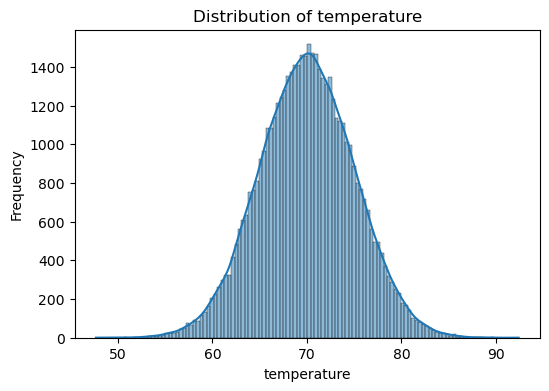

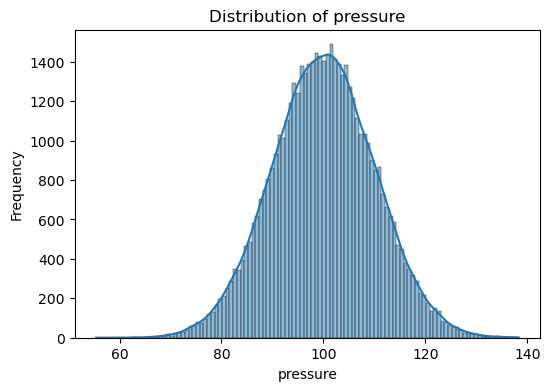

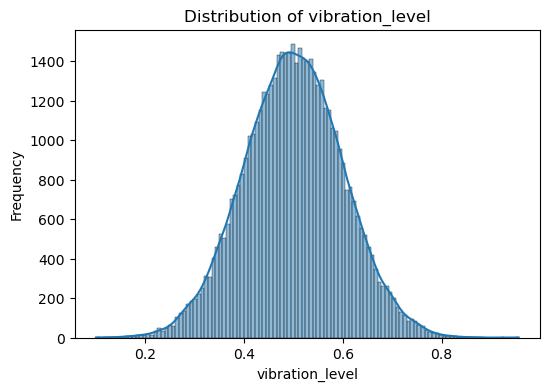

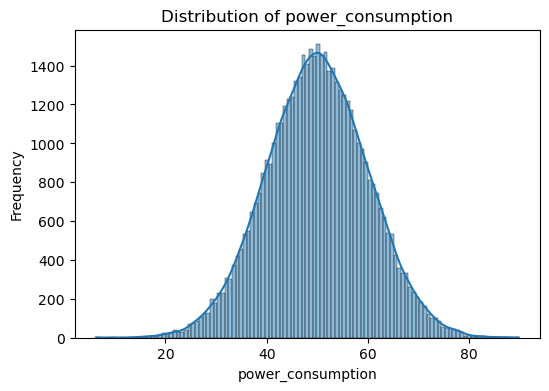

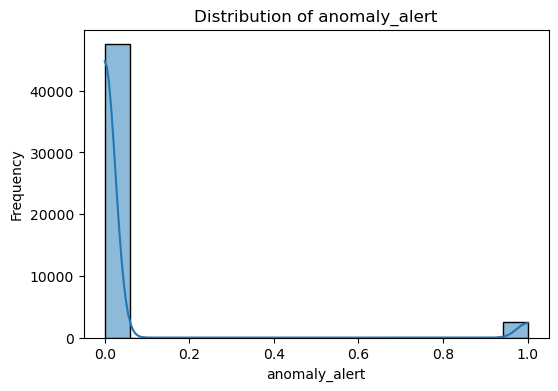

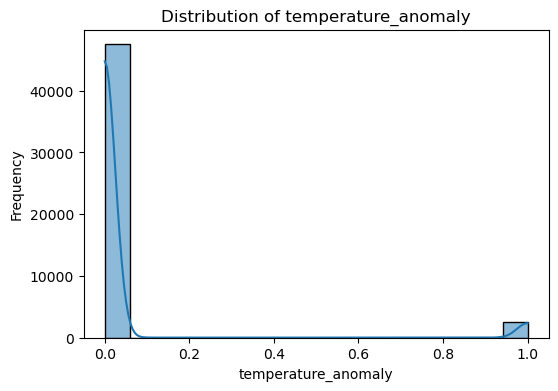

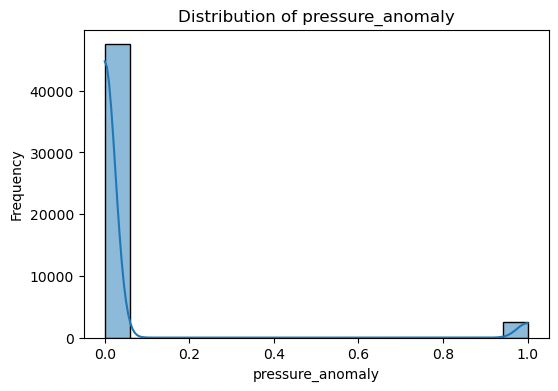

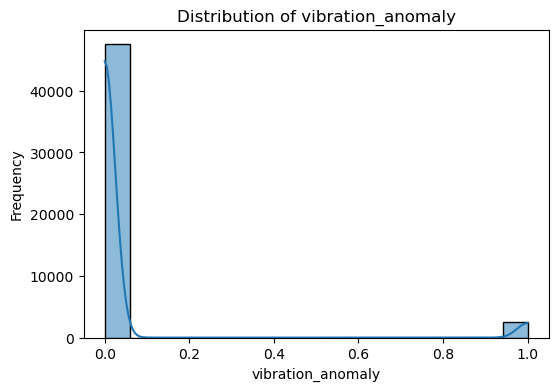

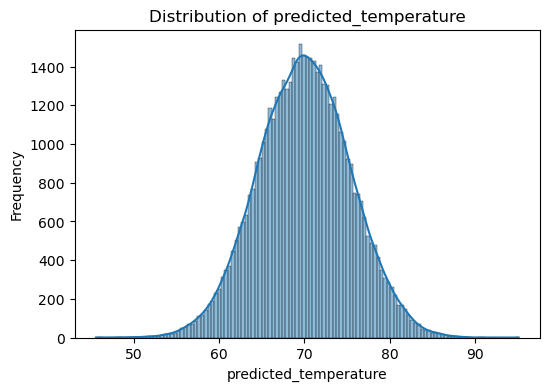

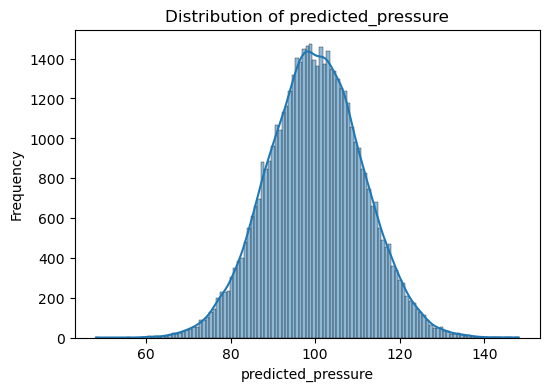

In [33]:
#Univariate Analysis – Numerical Features
# List of numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Histograms with KDE
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Univariate Analysis – 
Categorical Features -Bar plots for frequency counts of categorical columns

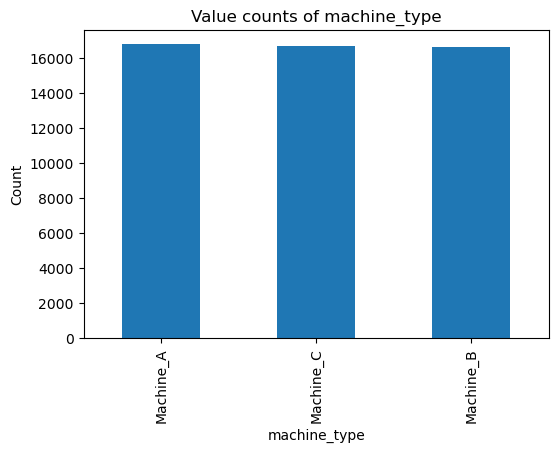

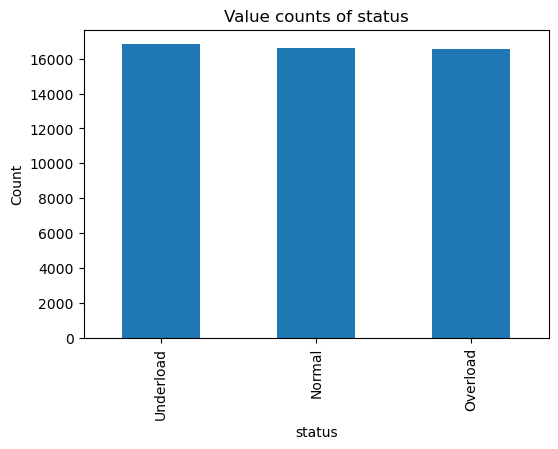

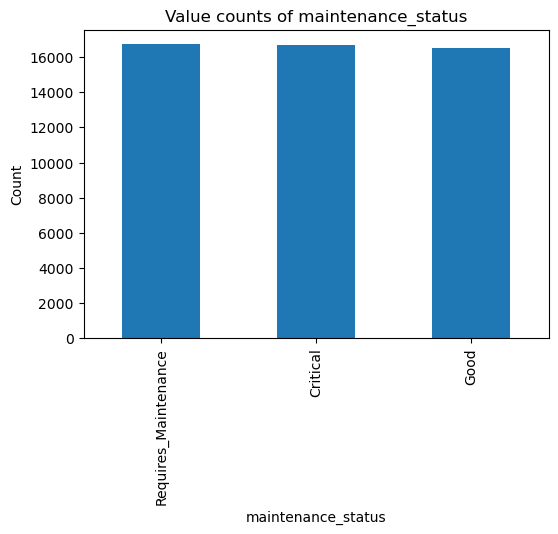

In [34]:
#Univariate Analysis – Categorical Features
# List of categorical columns
cat_cols = df.select_dtypes(include='object').columns
# Bar plots for categorical features
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Value counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Correlation Analysis -
Heatmap of correlation matrix for numerical features

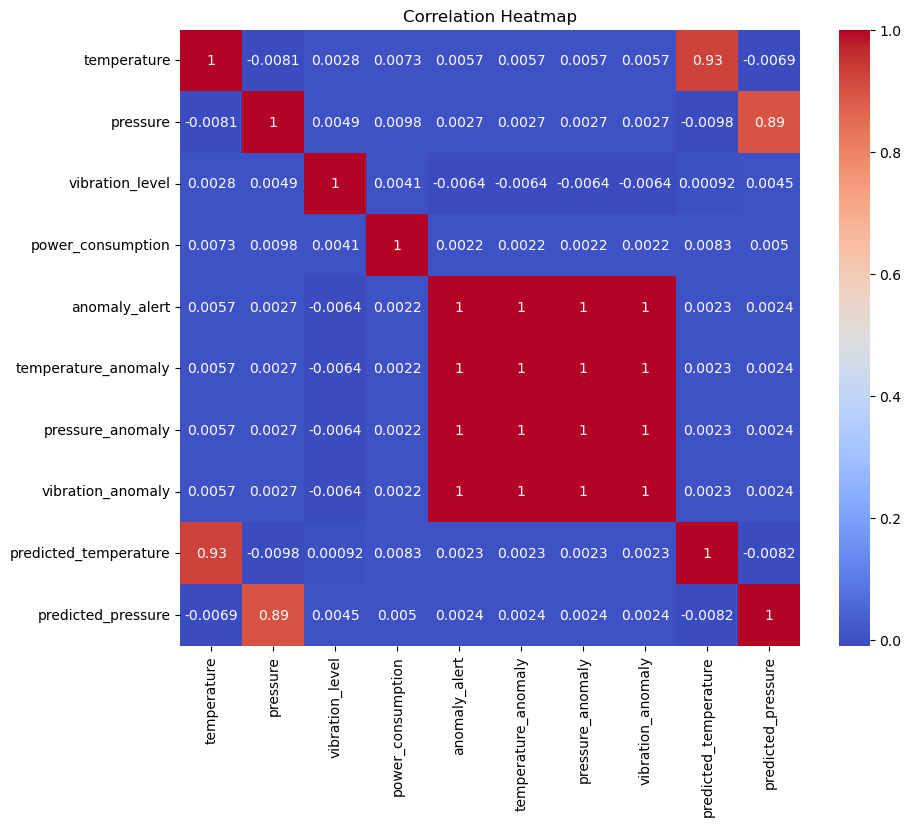

In [35]:
#Correlation Heatmap
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Pairwise Relationships -
Pairplot of selected numerical features

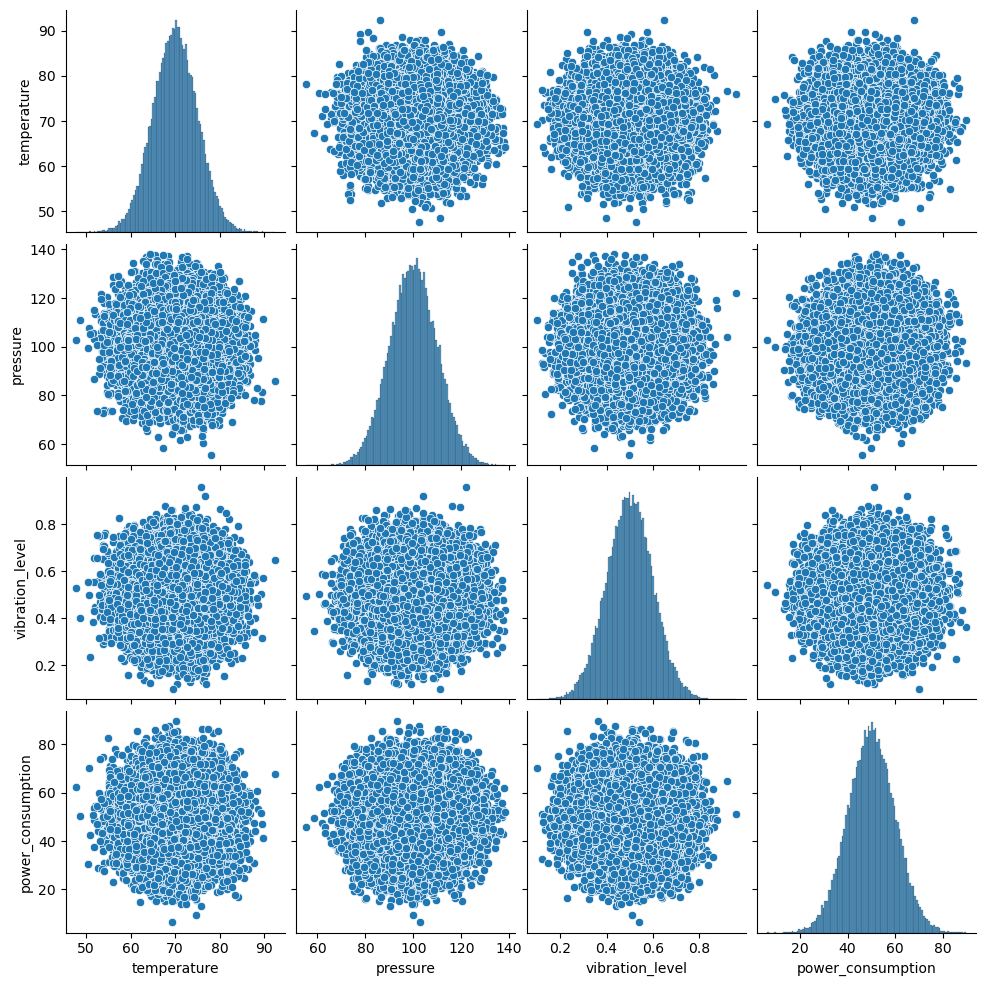

In [36]:
#Pairplot of Selected Features
# Pairplot for selected features
selected_features = ['temperature', 'pressure', 'vibration_level', 'power_consumption']
sns.pairplot(df[selected_features])
plt.show()

# Outlier Detection -
Boxplots for identifying outliers in key metrics

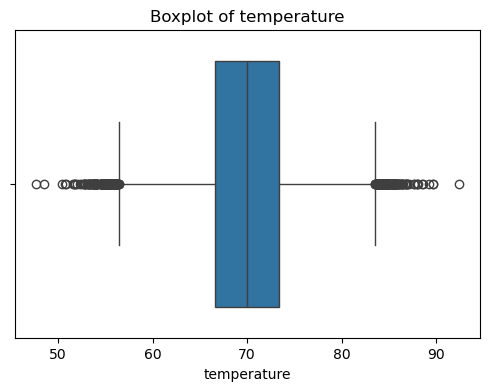

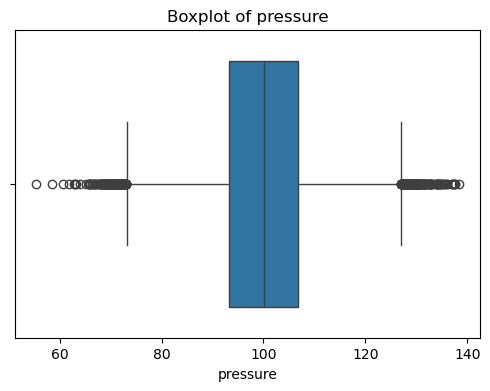

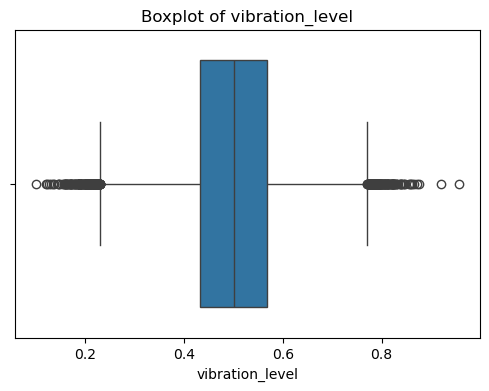

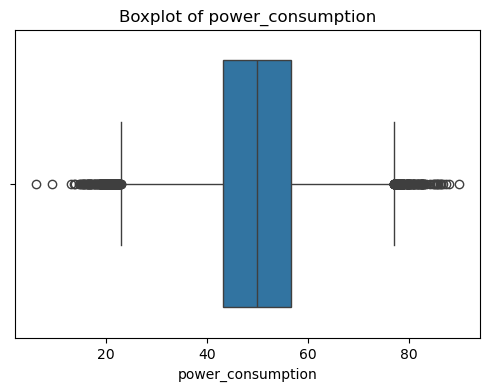

In [37]:
#Boxplots for Outlier Detection
# Boxplots to detect outliers
for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [38]:
# Numerical columns
num_cols = ['temperature', 'pressure', 'vibration_level', 'power_consumption']

def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df
df = remove_outliers(df, num_cols)
df.shape


(48671, 14)

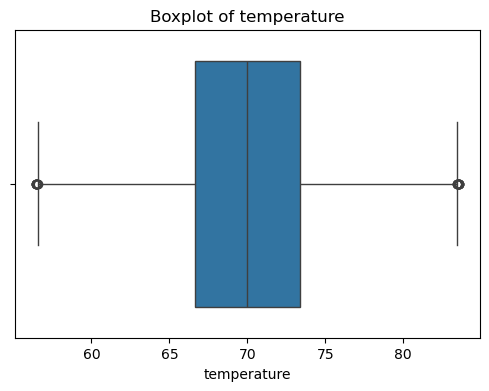

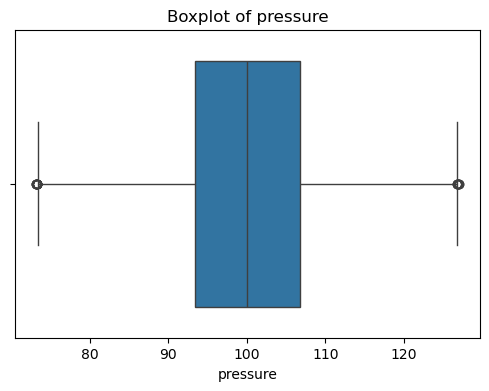

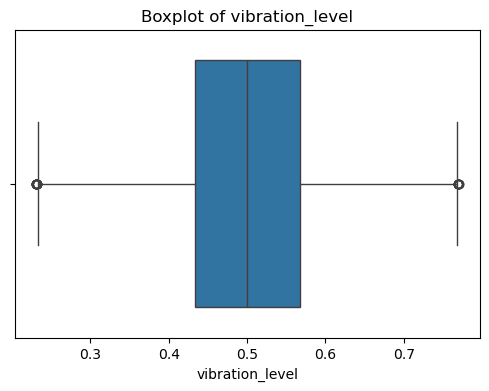

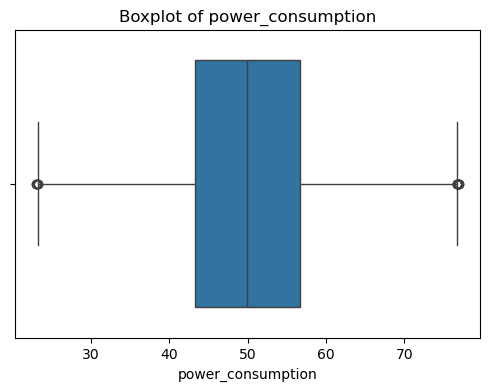

In [39]:
#Boxplots for Outlier Detection
# Boxplots to detect outliers
for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Time Series Visualization -
Line plot of temperature over time using the timestamp

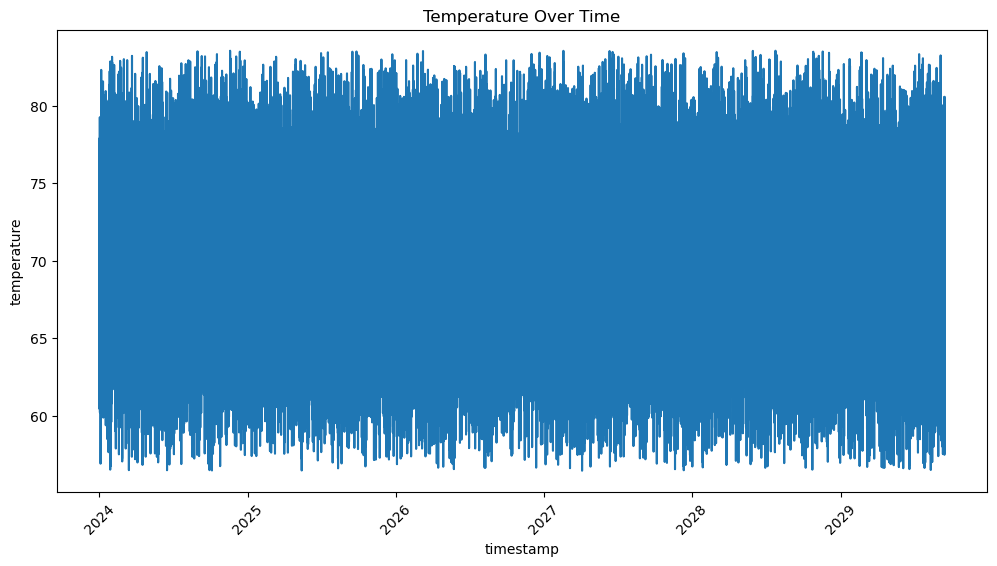

In [40]:
#Time Series Plot
# Line plot of temperature over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='temperature', data=df)
plt.title('Temperature Over Time')
plt.xticks(rotation=45)
plt.show()

# Grouped Analysis -
Mean values of metrics grouped by machine_type

In [41]:
#Grouped Analysis by Machine Type
# Grouped mean values
grouped = df.groupby('machine_type')[['temperature', 'pressure', 'vibration_level']].mean()
print("\nAverage metrics by machine type:\n", grouped)


Average metrics by machine type:
               temperature    pressure  vibration_level
machine_type                                          
Machine_A       69.974690   99.903281         0.500991
Machine_B       69.985325  100.097746         0.500319
Machine_C       70.036166  100.085883         0.500414


# Anomaly Flag Analysis -
Frequency counts of anomaly indicator columns

In [42]:
#Anomaly Column Analysis
# Count of anomaly flags
anomaly_cols = ['temperature_anomaly', 'pressure_anomaly', 'vibration_anomaly']
for col in anomaly_cols:
    print(f"\n{col} counts:\n", df[col].value_counts())


temperature_anomaly counts:
 temperature_anomaly
0    46264
1     2407
Name: count, dtype: int64

pressure_anomaly counts:
 pressure_anomaly
0    46264
1     2407
Name: count, dtype: int64

vibration_anomaly counts:
 vibration_anomaly
0    46264
1     2407
Name: count, dtype: int64


# Column mapping and Validations
we are making sure that the column existed in df 

In [43]:
# Column mapping & existence check
COLS = {
    "num": ['temperature', 'pressure', 'vibration_level', 'power_consumption'],
    "cat": ['machine_type', 'status', 'maintenance_status'],
    "ts": 'timestamp',
    "target_binary": 'anomaly_alert',
    "target_temp_anom": 'temperature_anomaly',
    "target_press_anom": 'pressure_anomaly',
    "target_vib_anom": 'vibration_anomaly'
}

# Quick validation: make sure expected columns exist in df
expected = []
for k, v in COLS.items():
    if isinstance(v, list):
        expected += v
    else:
        expected.append(v)

missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns in df: {missing}")

print("All expected columns exist. Proceeding...")


All expected columns exist. Proceeding...


# Shape Analysis of Data -

In [44]:
#  copy df and parse timestamp
data = df.copy()
data[COLS['ts']] = pd.to_datetime(data[COLS['ts']], errors='coerce')

# handle bad timestamps
if data[COLS['ts']].isnull().sum() > 0:
    data[COLS['ts']] = data[COLS['ts']].fillna(method='ffill')
data = data.dropna(subset=[COLS['ts']])
data.shape


(48671, 14)

# Finding and Filling the Null Values -
we are filling the numeric and categorical columns which are null and droping missing values

In [45]:
#  Numeric and categorical imputation
for c in COLS['num']:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].median())

for c in COLS['cat']:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].mode().iloc[0])

# drop rows missing main target
data = data.dropna(subset=[COLS['target_binary']])
for c in COLS['cat']:
    data[c] = data[c].astype(str)

print("Missing values handled. Rows now:", data.shape[0])


Missing values handled. Rows now: 48671


# Feature Engineering
- rolling mean for vibration (per machine if machine_id exists else global)
- replace inf/nan

In [46]:
#  Feature engineering
data['hour'] = data[COLS['ts']].dt.hour
data['dayofweek'] = data[COLS['ts']].dt.dayofweek
data['month'] = data[COLS['ts']].dt.month

data['temp_vib_ratio'] = data['temperature'] / (data['vibration_level'] + 1e-6)
data['press_power_ratio'] = data['pressure'] / (data['power_consumption'] + 1e-6)
data['is_critical_maintenance'] = (data['maintenance_status'].str.lower() == 'critical').astype(int)

# rolling mean for vibration (per machine if machine_id exists else global)
if 'machine_id' in data.columns:
    data = data.sort_values(['machine_id', COLS['ts']])
    data['vib_roll_mean_3'] = data.groupby('machine_id')['vibration_level'].transform(lambda x: x.rolling(3, min_periods=1).mean())
else:
    data = data.sort_values(COLS['ts'])
    data['vib_roll_mean_3'] = data['vibration_level'].rolling(3, min_periods=1).mean()

# replace inf/nan
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(data.median(numeric_only=True), inplace=True)

print("Feature engineering complete. Sample columns:", [c for c in data.columns if c not in df.columns][:10])


Feature engineering complete. Sample columns: ['hour', 'dayofweek', 'month', 'temp_vib_ratio', 'press_power_ratio', 'is_critical_maintenance', 'vib_roll_mean_3']


# Features and Encoding -
Label encode categorical columns (good for tree-based models)

In [47]:
#  Features and encoding
FEATURES = (COLS['num'] +
            ['hour', 'dayofweek', 'month',
             'temp_vib_ratio', 'press_power_ratio', 'is_critical_maintenance', 'vib_roll_mean_3'] +
            COLS['cat'])

# Label encode categorical columns (good for tree-based models)
le_map = {}
for c in COLS['cat']:
    le = LabelEncoder()
    data[c + '_enc'] = le.fit_transform(data[c].astype(str))
    le_map[c] = le

# Build final feature list replacing raw cats with encoded versions
FEATURES = [f for f in FEATURES if f not in COLS['cat']] + [c + '_enc' for c in COLS['cat']]
len(FEATURES), FEATURES[:10]


(14,
 ['temperature',
  'pressure',
  'vibration_level',
  'power_consumption',
  'hour',
  'dayofweek',
  'month',
  'temp_vib_ratio',
  'press_power_ratio',
  'is_critical_maintenance'])

# Split the DataSet into two - training and testing dataset

In [48]:
#  Split and scale
X = data[FEATURES]
y = data[COLS['target_binary']].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

num_cols_for_scaler = [c for c in X.columns if c in COLS['num'] + ['temp_vib_ratio', 'press_power_ratio', 'vib_roll_mean_3']]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_for_scaler] = scaler.fit_transform(X_train[num_cols_for_scaler])
X_test_scaled[num_cols_for_scaler] = scaler.transform(X_test[num_cols_for_scaler])

print("Train/Test sizes:", X_train.shape, X_test.shape)


Train/Test sizes: (38936, 14) (9735, 14)


#  Apply SMOTE 

In [49]:
!pip install imbalanced-learn

In [50]:
from imblearn.over_sampling import SMOTE
if SMOTE is not None:
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
    print("SMOTE applied:", X_train.shape, "->", X_res.shape)
else:
    X_res, y_res = X_train_scaled, y_train
    print("SMOTE not available; proceeding without resampling.")


SMOTE applied: (38936, 14) -> (74020, 14)


#  Train RandomForestClassifier and evaluate

In [51]:
rfc = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rfc.fit(X_res, y_res)

def eval_classification(model, X_t, y_t, model_name="Model"):
    y_pred = model.predict(X_t)
    try:
        y_proba = model.predict_proba(X_t)[:, 1]
    except Exception:
        y_proba = None
    print(f"\n=== {model_name} ===")
    print(classification_report(y_t, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_t, y_pred))
    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_t, y_proba))
    print("F1:", f1_score(y_t, y_pred))
    return y_pred

rfc_pred_test = eval_classification(rfc, X_test_scaled, y_test, "RandomForestClassifier (test)")



=== RandomForestClassifier (test) ===
              precision    recall  f1-score   support

           0     0.9507    0.9474    0.9490      9254
           1     0.0507    0.0541    0.0523       481

    accuracy                         0.9032      9735
   macro avg     0.5007    0.5007    0.5007      9735
weighted avg     0.9062    0.9032    0.9047      9735

Confusion matrix:
 [[8767  487]
 [ 455   26]]
ROC-AUC: 0.4915271791217329
F1: 0.052313883299798795


# XGBoost and evaluate

In [52]:
!pip install xgboost

In [53]:
import xgboost as xgb

In [54]:
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

In [55]:
if XGB_AVAILABLE:
    xclf = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
    xclf.fit(X_res, y_res)
    _ = eval_classification(xclf, X_test_scaled, y_test, "XGBoostClassifier (test)")
else:
    print("XGBoost not installed; skipped.")


=== XGBoostClassifier (test) ===
              precision    recall  f1-score   support

           0     0.9517    0.8517    0.8990      9254
           1     0.0557    0.1684    0.0838       481

    accuracy                         0.8180      9735
   macro avg     0.5037    0.5101    0.4914      9735
weighted avg     0.9074    0.8180    0.8587      9735

Confusion matrix:
 [[7882 1372]
 [ 400   81]]
ROC-AUC: 0.5098566131092606
F1: 0.08376421923474664


# Regression on temperature & pressureRegression on temperature & pressure

In [56]:
# Build training/test targets aligned with X splits
yr_temp_train = data.loc[X_train_scaled.index, 'temperature']
yr_temp_test  = data.loc[X_test_scaled.index, 'temperature']
yr_press_train = data.loc[X_train_scaled.index, 'pressure']
yr_press_test  = data.loc[X_test_scaled.index, 'pressure']


In [57]:
# RandomForestRegressor
rfr_temp = RandomForestRegressor(n_estimators=200, random_state=42)
rfr_temp.fit(X_train_scaled, yr_temp_train)
temp_pred = rfr_temp.predict(X_test_scaled)
print("Temperature RMSE:", mean_squared_error(yr_temp_test, temp_pred), "R2:", r2_score(yr_temp_test, temp_pred))

rfr_press = RandomForestRegressor(n_estimators=200, random_state=42)
rfr_press.fit(X_train_scaled, yr_press_train)
press_pred = rfr_press.predict(X_test_scaled)
print("Pressure RMSE:", mean_squared_error(yr_press_test, press_pred), "R2:", r2_score(yr_press_test, press_pred))

if XGB_AVAILABLE:
    xgr_temp = xgb.XGBRegressor(n_estimators=200, random_state=42)
    xgr_temp.fit(X_train_scaled, yr_temp_train)
    print("XGB Temp RMSE:", mean_squared_error(yr_temp_test, xgr_temp.predict(X_test_scaled)))
    y_pred_xgb = xgr_temp.predict(X_test_scaled)
    print("Predicted response of test data is :- ",y_pred_xgb)


Temperature RMSE: 1.1337651680966754e-06 R2: 0.9999999527376825
Pressure RMSE: 1.0399785359502908e-05 R2: 0.999999892112654
XGB Temp RMSE: 0.0032698712931516437
Predicted response of test data is :-  [73.76158  77.36217  69.876274 ... 72.70796  69.820656 64.701996]


#  IsolationForest + Autoencoder

In [58]:
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    KERAS_AVAILABLE = True
except ImportError:
    KERAS_AVAILABLE = False

In [59]:
iso_features = [f for f in ['vibration_level','temperature','pressure','power_consumption','vib_roll_mean_3','temp_vib_ratio','press_power_ratio'] if f in X_train_scaled.columns]
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_scaled[iso_features])
iso_pred_test = iso.predict(X_test_scaled[iso_features])
iso_pred_test_bin = (iso_pred_test == -1).astype(int)
print("IsolationForest vs labels:")
print(classification_report(y_test, iso_pred_test_bin, digits=4))
print("IF ROC-AUC (decision_function):", roc_auc_score(y_test, iso.decision_function(X_test_scaled[iso_features])))

# Autoencoder (if Keras available)
if KERAS_AVAILABLE:
    ae_features = iso_features
    X_ae_train = X_train_scaled[ae_features].values
    X_ae_test = X_test_scaled[ae_features].values

    # Train AE only on normal data (y_res == 0)
    normal_idx = (y_res == 0)
    if normal_idx.sum() < 10:
        X_ae_train_norm = X_ae_train
    else:
        X_ae_train_norm = X_res.loc[normal_idx, ae_features].values if hasattr(X_res, 'loc') else X_ae_train

    input_dim = X_ae_train.shape[1]
    encoding_dim = max(2, input_dim // 2)

    ae = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(encoding_dim*2, activation='relu'),
        layers.Dense(encoding_dim, activation='relu', name='bottleneck'),
        layers.Dense(encoding_dim*2, activation='relu'),
        layers.Dense(input_dim, activation='linear')
    ])
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_ae_train_norm, X_ae_train_norm, epochs=30, batch_size=64, validation_data=(X_ae_test, X_ae_test), verbose=0)

    recon_test = ae.predict(X_ae_test)
    mse_test = np.mean(np.square(recon_test - X_ae_test), axis=1)
    recon_train = ae.predict(X_ae_train_norm)
    mse_train = np.mean(np.square(recon_train - X_ae_train_norm), axis=1)
    thresh = mse_train.mean() + 3*mse_train.std()
    ae_pred_test_bin = (mse_test > thresh).astype(int)

    print("Autoencoder report (threshold mean+3std):")
    print("Threshold:", thresh)
    print(classification_report(y_test, ae_pred_test_bin, digits=4))
else:
    print("Keras not available; skipped Autoencoder.")


IsolationForest vs labels:
              precision    recall  f1-score   support

           0     0.9516    0.8994    0.9248      9254
           1     0.0586    0.1206    0.0789       481

    accuracy                         0.8609      9735
   macro avg     0.5051    0.5100    0.5018      9735
weighted avg     0.9075    0.8609    0.8830      9735

IF ROC-AUC (decision_function): 0.4904492612510767
Keras not available; skipped Autoencoder.


# Diagnostics and plots


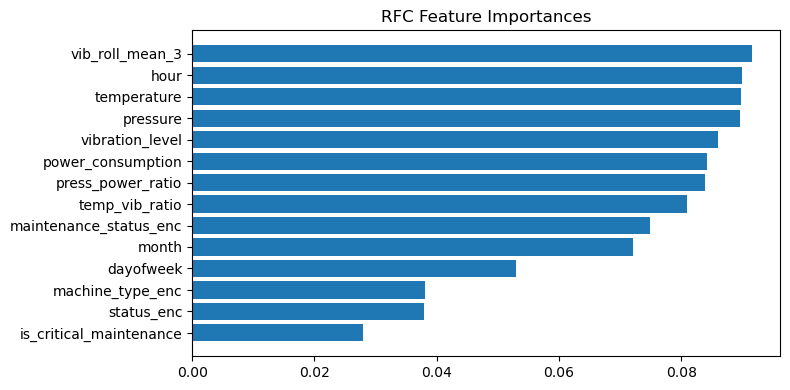

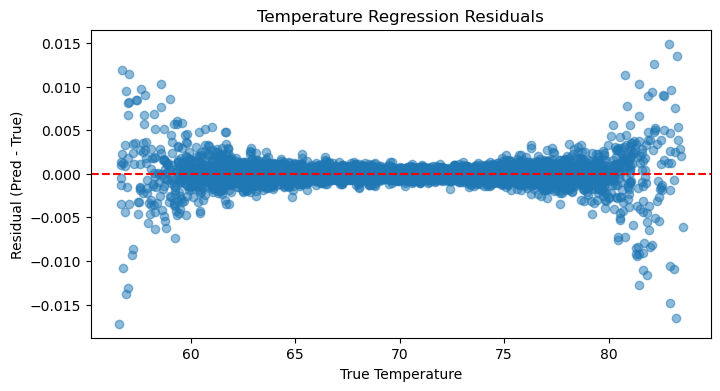

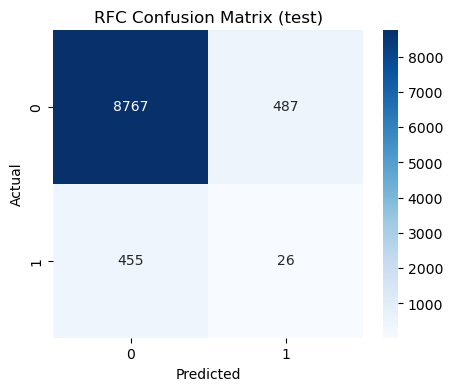

In [60]:
def plot_feature_importances(model, X_cols, top_n=20, title="Feature importances"):
    fi = pd.Series(model.feature_importances_, index=X_cols).sort_values(ascending=True).tail(top_n)
    plt.figure(figsize=(8, max(4, 0.25*len(fi))))
    plt.barh(fi.index, fi.values)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_feature_importances(rfc, X.columns, top_n=20, title="RFC Feature Importances")

# Regression residuals for temperature
plt.figure(figsize=(8,4))
plt.scatter(yr_temp_test, temp_pred - yr_temp_test, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("True Temperature")
plt.ylabel("Residual (Pred - True)")
plt.title("Temperature Regression Residuals")
plt.show()

# Confusion matrix for RFC
cm = confusion_matrix(y_test, rfc_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("RFC Confusion Matrix (test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#  Simple rule-based fallback

In [61]:
def rule_based_alert(row, vib_thresh=None, temp_thresh=None, press_thresh=None):
    if vib_thresh is None:
        vib_thresh = data['vibration_level'].quantile(0.95)
    if temp_thresh is None:
        temp_thresh = data['temperature'].mean() + 2*data['temperature'].std()
    if press_thresh is None:
        press_thresh = data['pressure'].mean() + 2*data['pressure'].std()
    if (row['vibration_level'] > vib_thresh) or (row['temperature'] > temp_thresh) or (row['pressure'] > press_thresh):
        return 1
    return 0

sample = data.sample(5, random_state=42).copy()
sample['rule_alert'] = sample.apply(rule_based_alert, axis=1)
sample[['vibration_level','temperature','pressure','rule_alert']]


,vibration_level,temperature,pressure,rule_alert
25224,0.380969,73.685114,90.397599,0
39499,0.287252,75.297133,110.648038,0
31585,0.550980,67.355472,91.852076,0
44786,0.486861,65.253933,92.440047,0
49912,0.524458,72.972446,105.316089,0


# LinearRegression
training model on linear Regression adn making prediction out of it.

In [62]:
# Create an instance of the LinearRegression class
Linear_model = LinearRegression()

# Fit the model to the training data to calculate the optimal intercept and slope
Linear_model.fit(X_train, y_train)

r_sq = Linear_model.score(X_train, y_train)
print(f"Coefficient of determination (R-squared): {r_sq}")
print(f"Intercept: {Linear_model.intercept_}") # The b0 value
print(f"Slope/Coefficient: {Linear_model.coef_}") # The b1 value(s)
y_pred_lr = Linear_model.predict(X_test)
print(f"Predicted responses for test data:\\n{y_pred_lr}")


Coefficient of determination (R-squared): 0.000467861415818005
Intercept: 0.01389298458244545
Slope/Coefficient: [ 9.66353911e-04 -3.84819320e-05 -9.29548240e-02  4.66835478e-04
  1.86580179e-04  9.02645368e-04  2.82649837e-04 -2.59868118e-04
  8.23048704e-03  3.12526182e-03  8.56671299e-03  6.62825910e-04
  8.72710481e-04  2.18717671e-03]
Predicted responses for test data:\n[0.04740217 0.04430576 0.05215432 ... 0.05712219 0.04425055 0.05264308]


# Linear Regression Visulize

In [63]:
# Evaluation
rmse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.04697655583827425
R² Score: -0.00018079871025378225


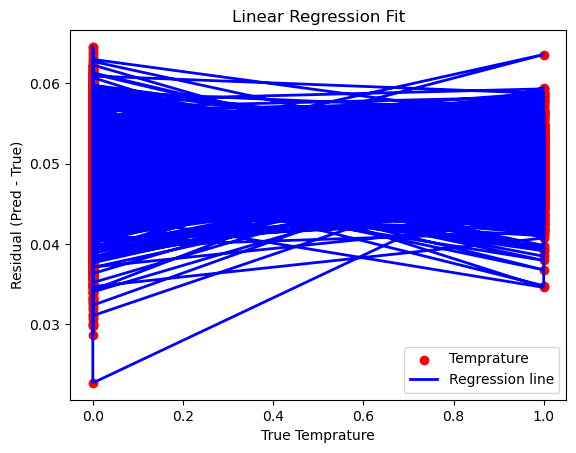

In [64]:
plt.scatter(y_test, y_pred_lr, color='red', label='Temprature')
plt.plot(y_test, y_pred_lr, color='blue', linewidth=2, label='Regression line')
plt.xlabel('True Temprature')
plt.ylabel('Residual (Pred - True)')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

# Gradient Desent using LinearRegression

In [65]:
import numpy as np

def gradient_descent(X, y, m, b, learning_rate, epochs):
    # Ensure numpy arrays and 1D
    X = np.asarray(X).reshape(-1)   # flatten if Series/DataFrame
    y = np.asarray(y).reshape(-1)

    n = len(X)  # number of samples

    for _ in range(epochs):
        # Predicted values
        y_pred_g = m * X + b

        # Gradients for MSE loss
        dm = (-2/n) * np.sum(X * (y - y_pred_g))
        db = (-2/n) * np.sum(y - y_pred_g)

        # Update parameters
        m = m - learning_rate * dm
        b = b - learning_rate * db

    return m, b


In [66]:
# Suppose df is your DataFrame
X = df['pressure']          # pandas Series
y = df['temperature']       # pandas Series

m = 0.0
b = 0.0
learning_rate = 0.0001      # often need smaller lr with real data
epochs = 5000

m, b = gradient_descent(X, y, m, b, learning_rate, epochs)

print(f"Optimized slope (m): {m}")
print(f"Optimized intercept (b): {b}")

# Predictions
X_np = np.asarray(X)
y_pred_gd = m * X_np + b


Optimized slope (m): -3.081958279440929e+43
Optimized intercept (b): -3.052158425382602e+41


# Gradeint Desent using LinearRegression Visualization

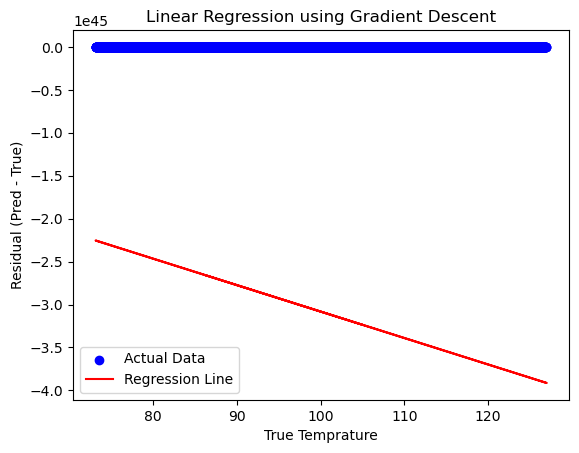

In [67]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred_gd, color='red', label='Regression Line')
plt.xlabel('True Temprature')
plt.ylabel('Residual (Pred - True)')
plt.title('Linear Regression using Gradient Descent')
plt.legend()
plt.show()

# Comparison in XGBoost and RandomForest

In [68]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [69]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost model
xgbr = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)

In [70]:
print("Random Forest Predictions:")
print(y_pred_rf[:10])

print("\nXGBoost Predictions:")
print(y_pred_xgb[:10])

Random Forest Predictions:
[0.025 0.095 0.055 0.06  0.165 0.1   0.14  0.025 0.07  0.065]

XGBoost Predictions:
[0.0887109  0.02155681 0.05550956 0.02267835 0.07674104 0.02517449
 0.14067568 0.03149568 0.02047093 0.07896237]


# Deploy my Model using Joblib

In [71]:
from joblib import dump

# Save the trained classifier
dump(rfc, "random_forest_classifier.joblib")
print("Model saved to random_forest_classifier.joblib")


Model saved to random_forest_classifier.joblib


In [72]:
dump(scaler, "feature_scaler.joblib")


['feature_scaler.joblib']

In [73]:
print(scaler.feature_names_in_)


['temperature' 'pressure' 'vibration_level' 'power_consumption'
 'temp_vib_ratio' 'press_power_ratio' 'vib_roll_mean_3']


In [74]:
# Checking my model Probablity by pas using RandomForest 

In [75]:
import pandas as pd
from joblib import load

# Load model
rfc = load("random_forest_classifier.joblib")

feature_cols = list(rfc.feature_names_in_)

sample = {
    "pressure": 95.2,
    "vibration_level": 0.51,
    "power_consumption": 45.3,
    "press_power_ratio": 95.2 / 45.3,     
    "temp_vib_ratio": 70.5 / 0.51,
    "temperature": 70.5,
    "vib_roll_mean_3": 0.49,
    "anomaly_alert": 0,
    "temperature_anomaly": 0,
    "pressure_anomaly": 0,
    "vibration_anomaly": 0,
    "sensor_mean": 1.22,
    "sensor_std": 0.14,
    "failure_score": 0.05
}

# Build DataFrame in correct order
X_new_df = pd.DataFrame([sample], columns=feature_cols)

# Predict
y_pred = rfc.predict(X_new_df)[0]
y_proba = rfc.predict_proba(X_new_df)[0, 1]  # probability for class 1

print("Predicted class:", y_pred)
print("Probability of class 1:", y_proba)


Predicted class: 0
Probability of class 1: 0.39


In [76]:
if y_proba > 0.7:
    print("⚠️ ALERT: High risk of machine failure!")
else:
    print("Machine operating normally.")

Machine operating normally.


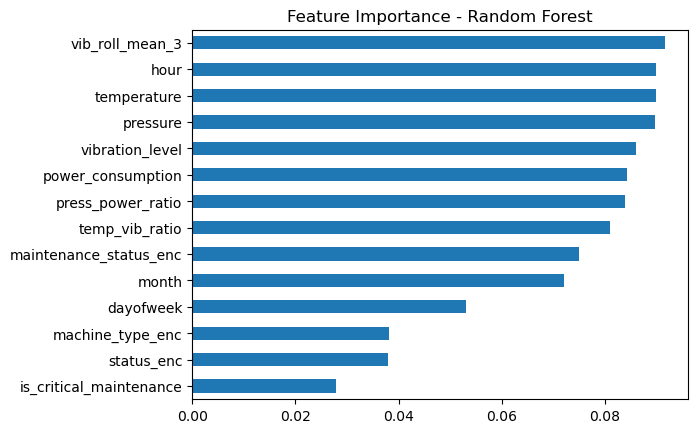

In [77]:
#Section name in notebook
importance = rfc.feature_importances_

feature_importance = pd.Series(importance, index=feature_cols)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance - Random Forest")
plt.show()

In [78]:
y_pred_rf_bin = (y_pred_rf > 0.5).astype(int)

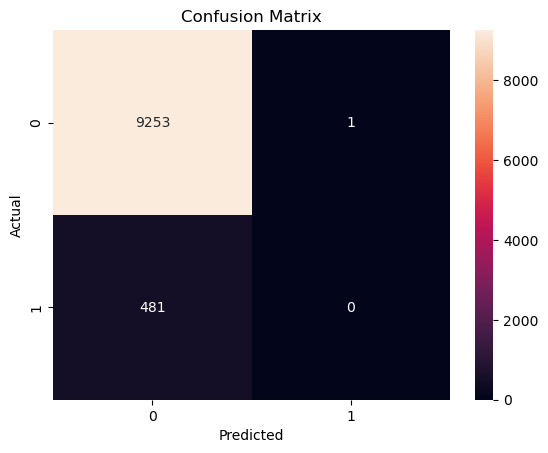

In [79]:
#Confusion Matrix Analysis
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf_bin)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#ROC Curve Evaluation
from sklearn.metrics import roc_curve, auc

y_probs = rfc.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

In [80]:
def predict_machine_status(sample):

    df = pd.DataFrame([sample], columns=feature_cols)

    pred = rfc.predict(df)[0]
    prob = rfc.predict_proba(df)[0,1]

    print("Prediction:", pred)
    print("Failure Probability:", prob)

    if prob > 0.7:
        print("⚠️ ALERT: Possible machine failure")

In [81]:
predict_machine_status(sample)

Prediction: 0
Failure Probability: 0.39


Conclusion

This project developed a machine anomaly detection system using
sensor data such as temperature, pressure, vibration, and power
consumption. Multiple machine learning models were evaluated
including Isolation Forest, Random Forest, and XGBoost.
Random Forest achieved the best predictive performance and
was selected as the final model. The system can detect abnormal
machine behavior and estimate the probability of equipment failure.